# Plotting code
Used for generating the boxplots. The code may not be pretty, but I would argue the plots are.

In [1]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import pathlib
from typing import NamedTuple
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
BASE_DIR = "../results"

In [26]:
class Eval(NamedTuple):
    normalized_returns: np.ndarray
    raw_returns: np.ndarray
    # steps: np.ndarray


def load_data(
    base: str = BASE_DIR,
    partition: str = "old-results",
    name: str = "Hopper-v2",
    expert: bool = True,
    beta: float = 1.0,
    eval_dir: str = "eval",
) -> Eval:
    path = f"*_FairDICE_MO-{name}_{'expert' if expert else 'amateur'}_uniform_SOFT_CHI_beta{beta}_seed*"
    norm_ret, raw_ret = [], []
    for directory in pathlib.Path(base, partition).glob(path):
        try:
            norm_ret.append(
                np.load(next(directory.glob(f"{eval_dir}/normalized_returns*.npy")))
            )
            raw_ret.append(
                np.load(next(directory.glob(f"{eval_dir}/raw_returns*.npy")))
            )
            # steps.append(np.load(next(directory.glob(f"{eval_dir}/steps*.npy"))))
        except StopIteration:
            continue
    if not norm_ret:
        raise FileNotFoundError(
            f"No data for {name=} {expert=} {beta=}, at {pathlib.Path(base, partition)}, looking for {path}"
        )

    return Eval(
        np.stack(norm_ret),
        np.stack(raw_ret),
        # np.stack(steps),
    )


load_data(
    name="Hopper-v2", expert=True, partition="bc-results", beta=1.0
).normalized_returns.shape

(10, 50, 2)

In [6]:
def avg_nash_social_welfare(returns: np.ndarray):
    # returns: [Seeds, Rollouts, Objectives]
    return np.nanmean(np.log(returns).sum(2), axis=1)


avg_nash_social_welfare(
    load_data(
        expert=False, name="Walker2d-v2", eval_dir="re-eval-100"
    ).normalized_returns
)

array([11.34166089, 11.42950268, 11.51286781, 11.62162421, 11.36984868,
       11.36537383, 11.60217336, 11.33092127, 11.43071999, 11.36370634])

In [7]:
standard_partitions = (
    "old-results",
    "bc-results",
    "fix-results-grad0",
    "fix-results-grad0.0001",
    "fix-results-grad0.1",
)
avg_nash_social_welfare(
    load_data(
        expert=True, name="Hopper-v3", beta=1e-5, partition=standard_partitions[2]
    ).normalized_returns
).mean()

np.float64(8.528260938560466)

In [10]:
standard_betas = (0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0)
centre_betas = (0.0001, 0.001, 0.01, 0.1, 1.0)


def gather_nsw_data(
    name: str = "Hopper-v2",
    expert: bool = True,
    betas: tuple[float, ...] = standard_betas,
    partitions: tuple[str, ...] = standard_partitions,
    eval_dir: str = "eval",
    normalise_returns: bool = True,
):
    return np.stack(
        [
            np.stack(
                [
                    avg_nash_social_welfare(
                        load_data(
                            name=name,
                            expert=expert,
                            partition=part,
                            beta=beta,
                            eval_dir=eval_dir,
                        ).normalized_returns
                        if normalise_returns
                        else load_data(
                            name=name,
                            expert=expert,
                            partition=part,
                            beta=beta,
                            eval_dir=eval_dir,
                        ).raw_returns
                    )
                    for part in partitions
                ]
            )
            for beta in betas
        ]
    )


# sometimes we get a negative final normalised return,
# because the learned FairDICE policy is significantly
# worse than the data policy. We ignore these and take
# the average over positive returns, which benefits
# FairDICE-fixed slightly (but this only occurs in
# evaluations which are already much worse than the
# baselines, so it doesn't really matter)
np.seterr(invalid="ignore")
# 'Mean of empty slice' indicates that we didn't have
# any positive returns at all, in which case we ommit that
# configuration from the later plots
gather_nsw_data(
    name="Hopper-v3", expert=True, eval_dir="re-eval-100", normalise_returns=True
).shape

(7, 5, 10)

In [28]:
from matplotlib import patches


def legend_handles(
    cols: tuple[tuple[float, float, float] | str, ...] = (
        *plt.color_sequences["Pastel1"][:2],
        "#DAECC8",
        "#A2DFA3",
        "#6ECDA7",
    ),
    hatches: tuple[str, ...] = ("O", ".", "x", "\\", "/"),
    group_names: tuple[str, ...] = (
        "FairDICE: Rerun GitHub",
        "Behaviour Cloning",
        "FairDICE: Fixed, $\\lambda=0$",
        "FairDICE: Fixed, $\\lambda=0.001$",
        "FairDICE: Fixed, $\\lambda=0.1$",
    ),
    # Full group names (scrapped due to space):
    # group_names: tuple[str, ...] = (
    #     "FairDICE: as implemented on GitHub",
    #     "Behavioural Cloning",
    #     "FairDICE: as described (fixed broadcast, gradient penalty $\\lambda=0$)",
    #     "FairDICE: fixed broadcasting, $\\lambda=0.001$",
    #     "FairDICE: fixed broadcasting, $\\lambda=0.1$",
    # ),
):
    return [
        patches.Patch(facecolor=col, hatch=hatch * 3, label=label, edgecolor="white")
        for col, hatch, label in zip(cols, hatches, group_names)
    ]


def grouped_bars(
    ax: plt.Axes,
    xs: npt.NDArray | tuple[float, ...],
    yss: npt.NDArray,
    cols: tuple[tuple[float, float, float] | str, ...] = (
        *plt.color_sequences["Pastel1"][:2],
        "#DAECC8",
        "#A2DFA3",
        "#6ECDA7",
    ),
    dark_cols: tuple[str, ...] = (
        "#7C0F05",
        "#264864",
        "#306723",
        "#216022",
        "#23644A",
    ),
    hatches: tuple[str, ...] = ("O", ".", "x", "\\", "/"),
    group_names: tuple[str, ...] = (
        "FairDICE: Rerun GitHub",
        "Behaviour Cloning",
        "FairDICE: Fixed, $\\lambda=0$",
        "FairDICE: Fixed, $\\lambda=0.001$",
        "FairDICE: Fixed, $\\lambda=0.1$",
    ),
    autorange_groups: int | None = None,
    kind: str = "bars",
    legend: bool = True,
    detailed_labels: bool = True,
):
    num_groups, group_size, num_seeds = yss.shape
    assert num_groups == len(xs), f"{len(xs)=} but {yss.shape=}"
    tick_positions, tick_labels = [], []
    group_gap = 0.03
    if kind == "rects":
        per_bar_size = (1.0 - (num_groups + 1) * group_gap) / (num_groups * group_size)
        x_pos = group_gap
    elif kind == "boxplot":
        per_bar_size = (1.0 - (num_groups - 1) * group_gap) / (group_size * num_groups)
        x_pos = per_bar_size / 2
    else:
        per_bar_size = (1.0 - (num_groups - 1) * group_gap) / (num_groups * group_size)
        x_pos = 0

    for group_idx, group_label in enumerate(xs):
        positions = x_pos + np.arange(group_size) * per_bar_size
        if kind == "boxplot":
            boxes = ax.boxplot(
                yss[group_idx].T,
                positions=positions,
                widths=per_bar_size,
                patch_artist=True,
            )
            for i, (patch, col, drk, hatch) in enumerate(
                zip(boxes["boxes"], cols, dark_cols, hatches)
            ):
                patch.set_facecolor(col)
                patch.set_hatch(hatch * 2)
                patch.set_edgecolor("white")
                boxes["medians"][i].set_color(drk)
                boxes["fliers"][i].set_markeredgecolor(drk)
                for idx in range(i * 2, (i + 1) * 2):
                    boxes["whiskers"][idx].set_color(drk)
                    boxes["caps"][idx].set_color(drk)

        elif kind == "rects":
            for ys, pos, col, drk, hatch in zip(
                yss[group_idx], positions, cols, dark_cols, hatches
            ):
                rect = patches.Rectangle(
                    (pos, ys.min()),
                    per_bar_size,
                    ys.max() - ys.min(),
                    facecolor=col,
                    hatch=hatch,
                )
                ax.add_patch(rect)

                ax.plot(
                    [pos, pos + per_bar_size],
                    [ys.mean(), ys.mean()],
                    color=drk,
                    linewidth=2,
                    solid_capstyle="butt",
                )
        elif kind == "bars":
            for ys, pos, col, drk, hatch in zip(
                yss[group_idx], positions, cols, dark_cols, hatches
            ):
                # mid = ys.mean()
                low, mid, hig = np.percentile(ys, (20, 50, 80))
                ax.bar(
                    pos, mid, width=per_bar_size, align="edge", color=col, hatch=hatch
                )
                low_err, hig_err = max(mid - low, 0), max(hig - mid, 0)
                ax.errorbar(
                    pos + per_bar_size / 2, mid, ((low_err,), (hig_err,)), color=drk
                )

        tick_positions.append(x_pos + (group_size - 1) / 2 * per_bar_size)
        tick_labels.append(str(group_label))
        x_pos += per_bar_size * group_size + group_gap
        if group_idx != len(xs) - 1:
            ax.axvline(
                x_pos - (group_gap + per_bar_size) / 2,
                color="#CCCCCC",
                linestyle="dashed",
                linewidth=0.8,
            )

    ax.set_xticks(tick_positions, tick_labels)
    ax.set_xlim(0, 1)
    if kind != "bars":
        yss_max = np.nanmax(yss)
        yss_min = np.nanmin(np.nanpercentile(yss[:, autorange_groups], 20, axis=-1))
    else:
        yss_max = np.nanmax(np.nanpercentile(yss, 80, axis=-1))
        yss_min = np.nanmin(np.nanpercentile(yss[:, autorange_groups], 20, axis=-1))
    y_margin = (yss_max - yss_min) * 0.05
    ax.set_ylim(yss_min - y_margin, yss_max + y_margin)

    if legend:
        legend_elements = legend_handles(cols, hatches, group_names)
        ax.legend(handles=legend_elements, loc="lower right")
    ax.grid(False)
    ax.grid(axis="y", linestyle="dashed")
    if detailed_labels:
        ax.set_xlabel("$\\beta$ (higher constrains policy closer to data)")
        ax.set_ylabel("Normalised Nash Social Welfare")
    else:
        ax.set_xlabel("$\\beta$")
        ax.set_ylabel("Normalised NSW")
        ticks = ax.get_yticks()
        if len(ticks) > 4:
            step = len(str(ticks[1])) < len(str(ticks[0]))
            ax.set_yticks(ticks[step::2])

In [29]:
import itertools

model_names = (
    "Hopper-v2",
    "Hopper-v3",
    "Swimmer-v2",
    "Walker2d-v2",
    "Ant-v2",
    "HalfCheetah-v2",
)
name_mapping = {
    "Hopper-v2": "Hopper (2 objectives)",
    "Swimmer-v2": "Swimmer",
    "Walker2d-v2": "Walker2d",
    "Ant-v2": "Ant",
    "HalfCheetah-v2": "HalfCheetah",
    "Hopper-v3": "Hopper (3 objectives)",
    "GroupPolicy-v1": "Group Policy",
}

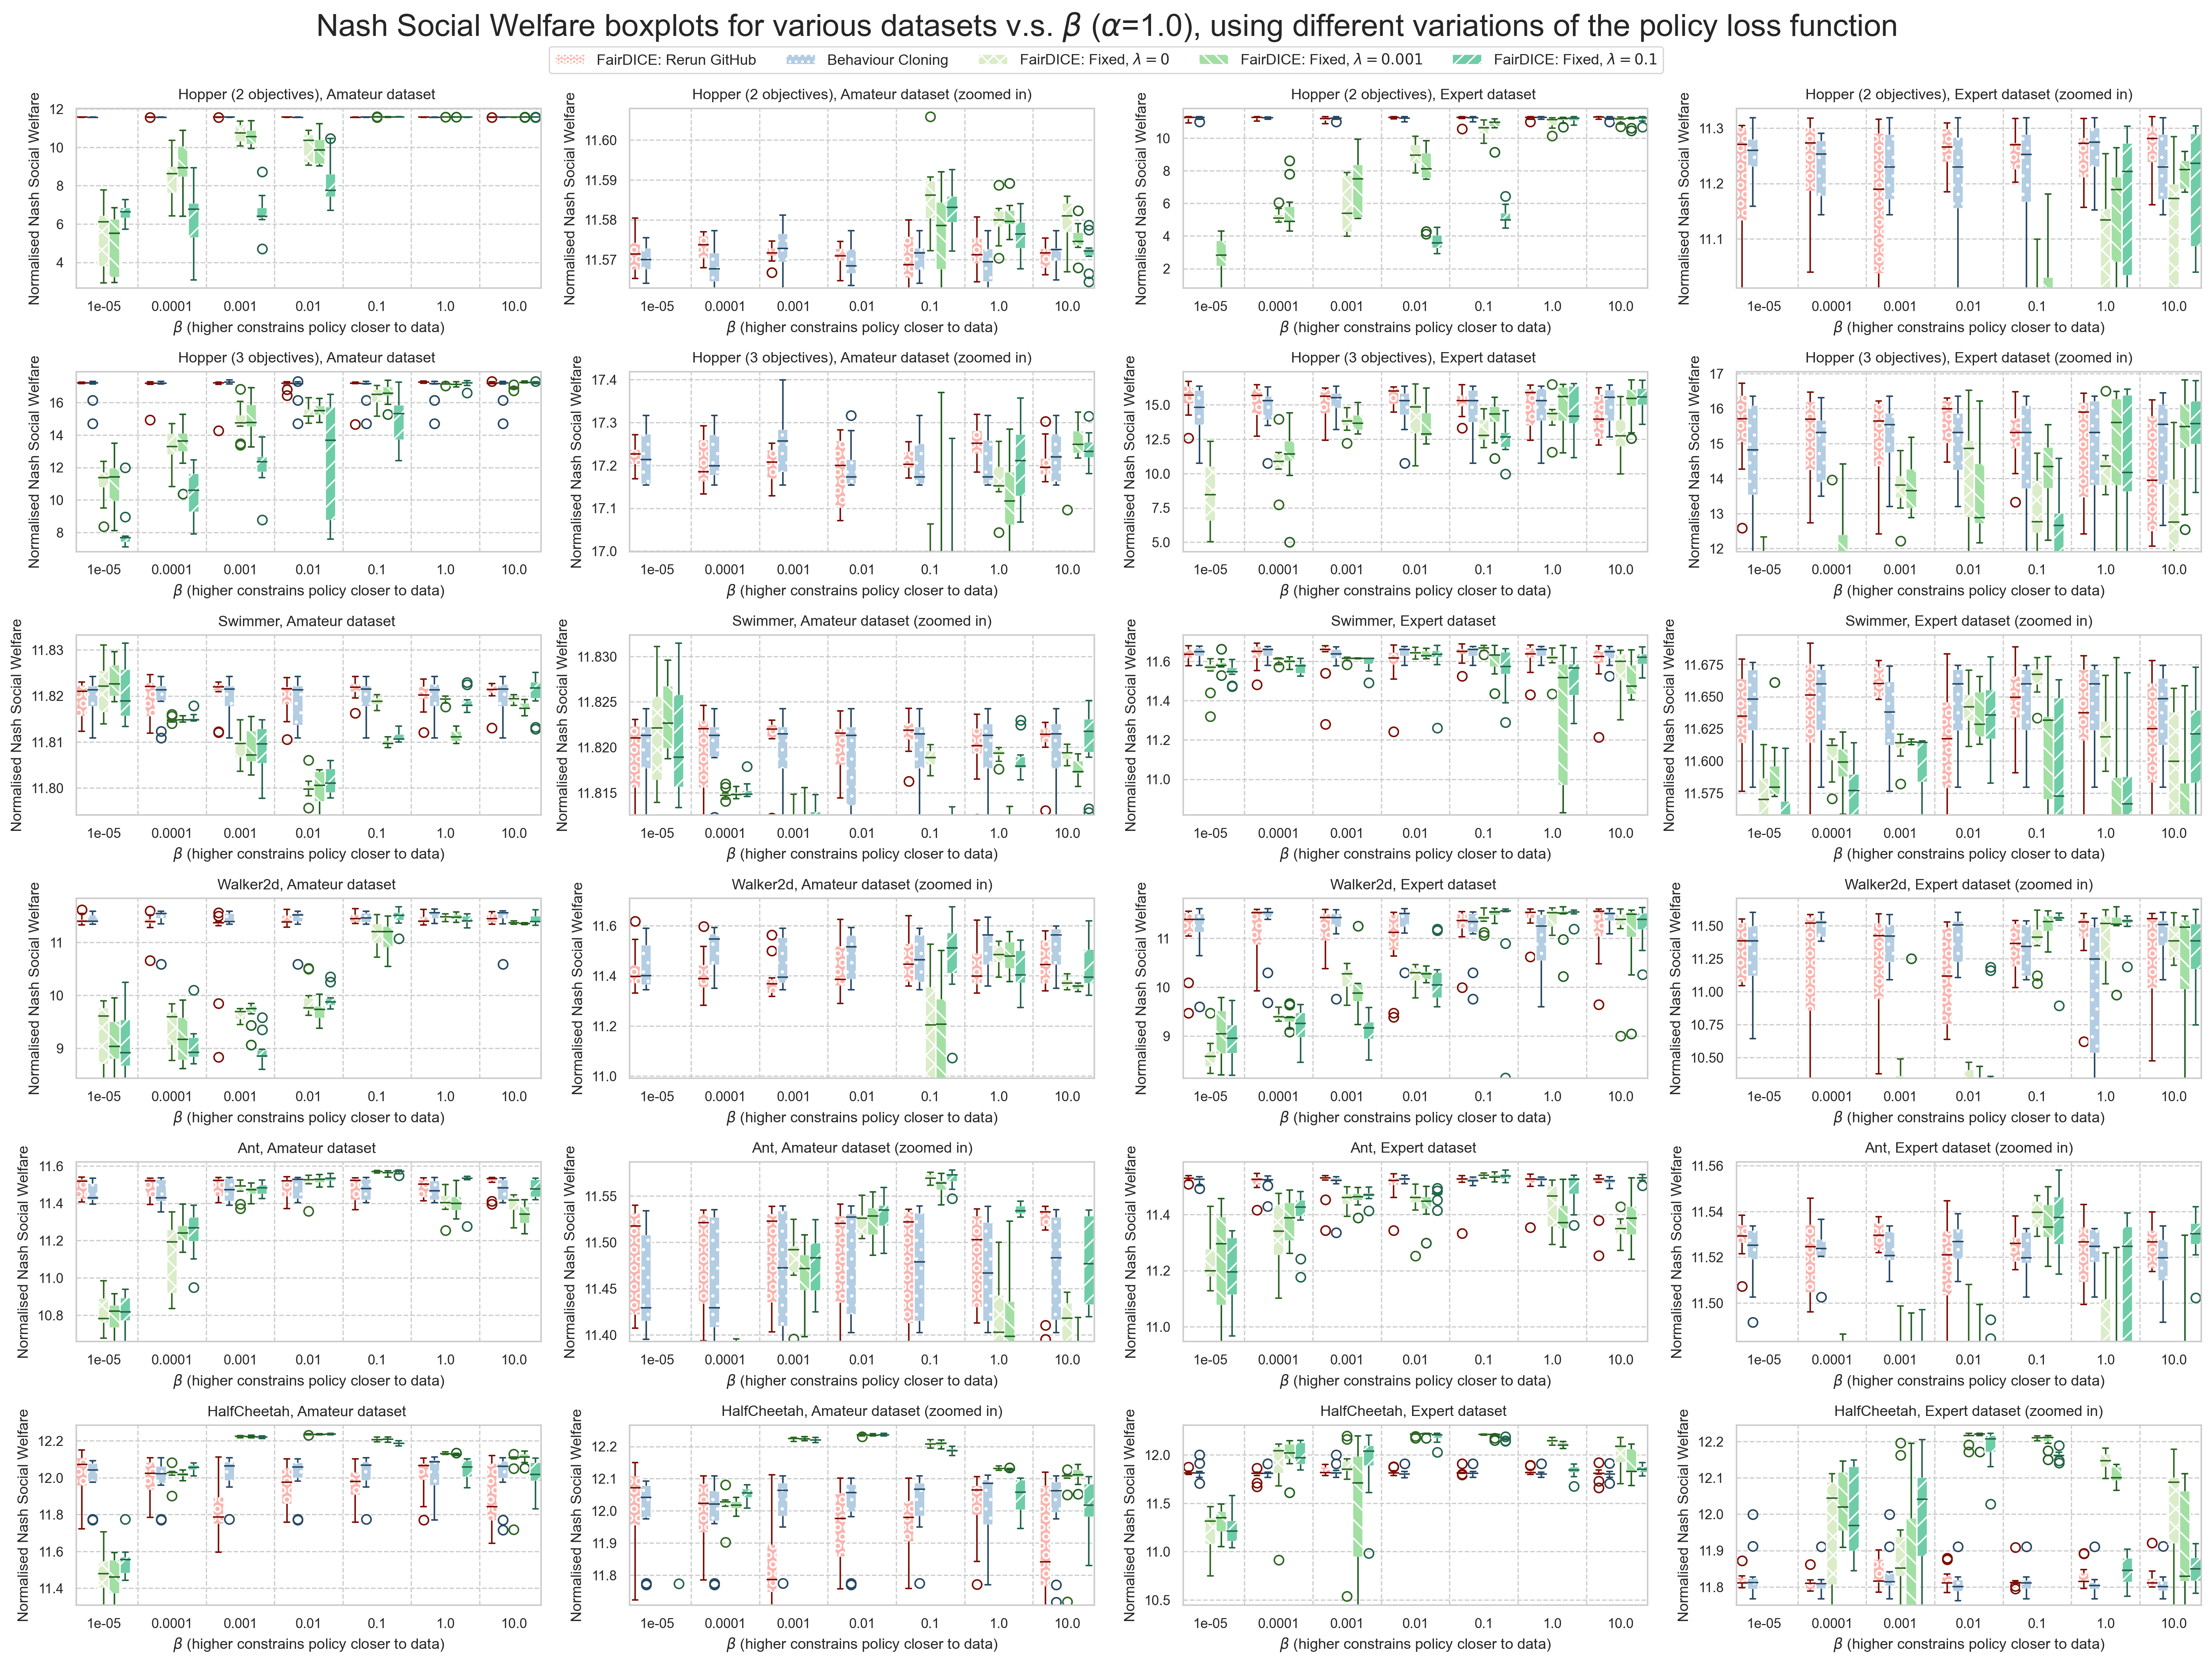

In [14]:
def make_box_grid(
    targets: tuple[tuple[str, bool, bool], ...] = tuple(
        itertools.product(model_names, (False, True), (False, True))
    ),
    ncols: int = 4,
    betas: tuple[float, ...] = standard_betas,
    partitions: tuple[str, ...] = (
        "old-results",
        "bc-results",
        "fix-results-grad0",
        "fix-results-grad0.0001",
        "fix-results-grad0.1",
    ),
    kind: str = "bars",
    figsize=(40, 15),
    title="Nash Social Welfare boxplots for various datasets v.s. $\\beta$ ($\\alpha$=1.0), using different variations of the policy loss function",
    legend_pos=0.978,
    figures_high=0.958,
    eval_dir: str = "re-eval-100",
    normalise_returns: bool = True,
    dark_cols: tuple[str, ...] = (
        "#7C0F05",
        "#264864",
        "#306723",
        "#216022",
        "#23644A",
    ),
    mosaic: str | None = None,
    only_detailed_on: list[bool] | None = None,
    legend_cols: int | None = None,
    fontsize: str | int = "medium",
    **style_kwargs,
):
    if mosaic is None:
        assert len(targets) % ncols == 0
        fig, axss = plt.subplots(
            nrows=len(targets) // ncols,
            ncols=ncols,
            tight_layout=True,
            figsize=figsize,
            dpi=300,
        )
        ax_iter = axss.flat
    else:
        fig, axss = plt.subplot_mosaic(
            mosaic, tight_layout=True, figsize=figsize, dpi=300
        )
        ax_iter = axss.values()

    if only_detailed_on is None:
        only_detailed_on = [True] * len(targets)
    for (name, expert, zoom), ax, detail in zip(
        targets, ax_iter, only_detailed_on, strict=True
    ):
        data = gather_nsw_data(
            betas=betas,
            expert=expert,
            name=name,
            partitions=partitions,
            eval_dir=eval_dir,
            normalise_returns=normalise_returns,
        )
        grouped_bars(
            ax,
            betas,
            data,
            kind=kind,
            autorange_groups=0 if zoom else None,
            legend=False,
            dark_cols=dark_cols,
            detailed_labels=detail,
            **style_kwargs,
        )
        ax.set_title(
            f"{name_mapping[name]}, {'Expert' if expert else 'Amateur'} dataset {'(zoomed in)' if zoom else ''}"
        )

    if title:
        fig.text(
            0.5,
            0.995,
            title,
            {"fontsize": 20},
            horizontalalignment="center",
            verticalalignment="top",
        )
    handles = legend_handles(**style_kwargs)
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, legend_pos),
        ncol=legend_cols or len(handles),
        fontsize=fontsize,
    )
    fig.tight_layout(rect=(0, 0, 1, figures_high))
    plt.show()


sns.set_context("paper")
make_box_grid(kind="boxplot", figsize=(20, 15), eval_dir="re-eval-100")
sns.set_context("notebook")

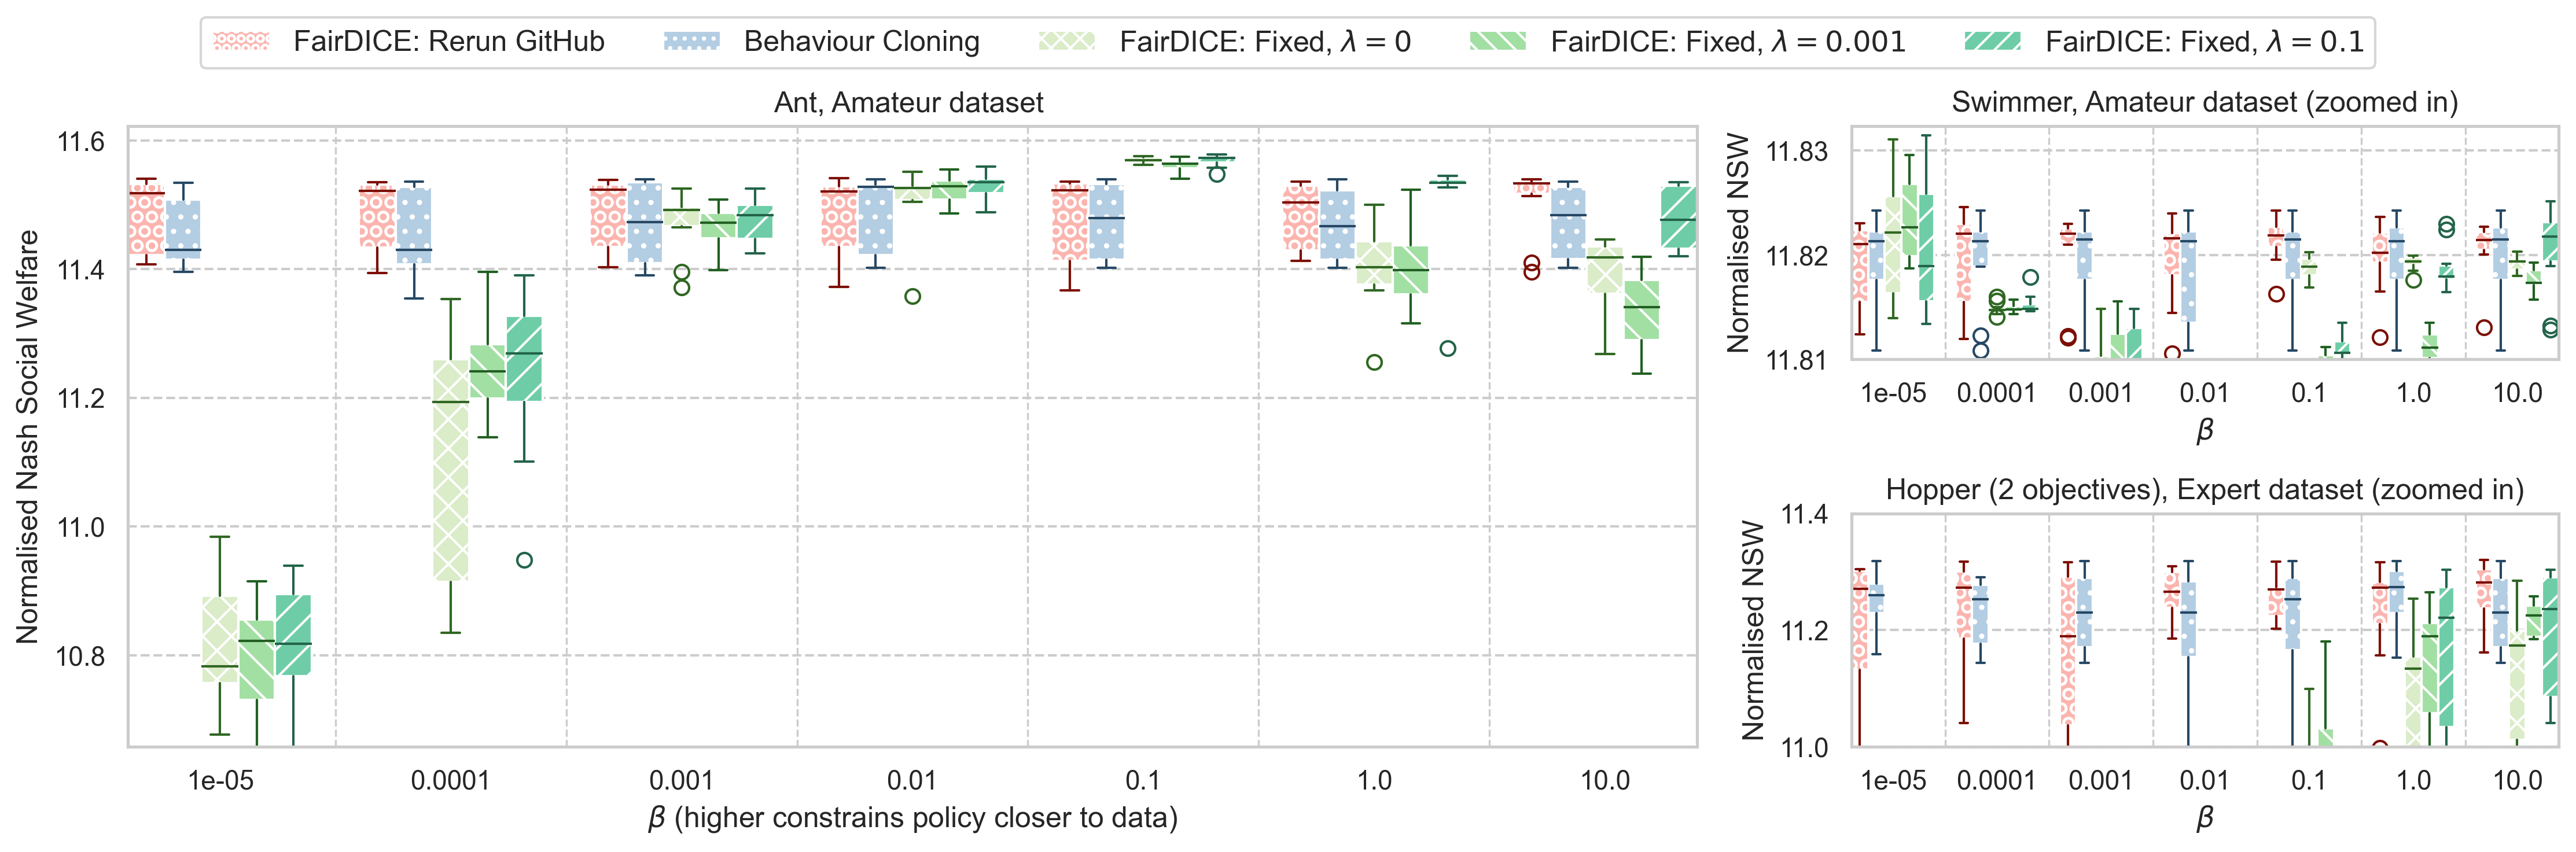

In [15]:
make_box_grid(
    kind="boxplot",
    figsize=(15, 5),
    ncols=3,
    targets=(
        ("Ant-v2", False, False),
        ("Swimmer-v2", False, True),
        ("Hopper-v2", True, True),
    ),
    title="",
    legend_pos=0.995,
    figures_high=0.93,
    mosaic="AAB;AAC",
    only_detailed_on=[True, False, False],
)

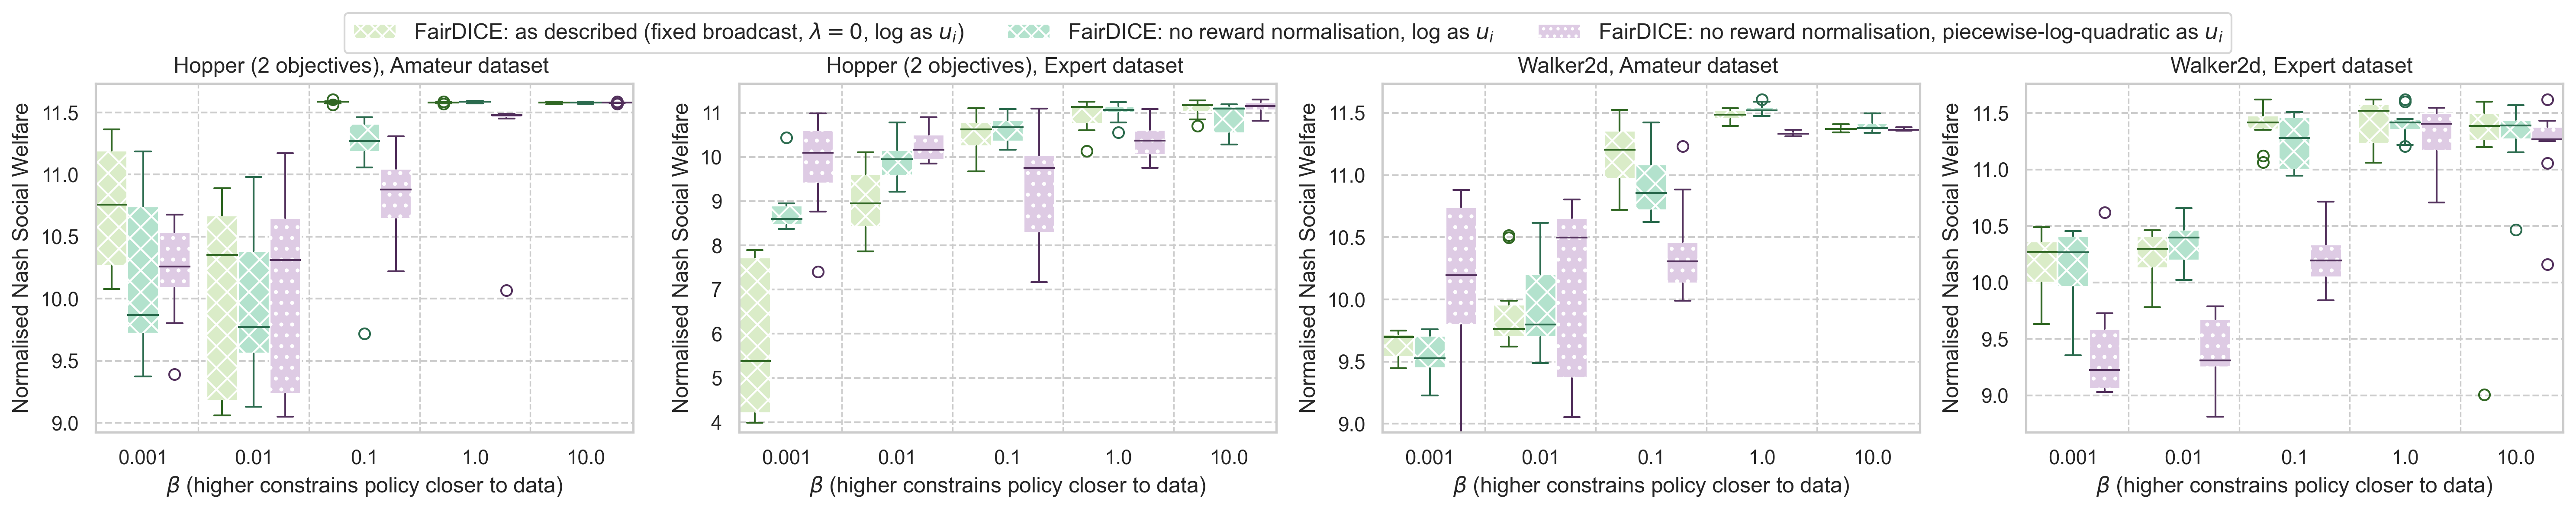

In [20]:
make_box_grid(
    kind="boxplot",
    partitions=("fix-results-grad0", "log-results", "piecewise-log-quadratic-results"),
    cols=(
        "#DAECC8",
        plt.color_sequences["Pastel2"][0],
        plt.color_sequences["Pastel1"][3],
    ),
    hatches=("x", "X", "."),
    group_names=(
        "FairDICE: as described (fixed broadcast, $\\lambda=0$, log as $u_i$)",
        "FairDICE: no reward normalisation, log as $u_i$",
        "FairDICE: no reward normalisation, piecewise-log-quadratic as $u_i$",
    ),
    betas=(0.001, 0.01, 0.1, 1.0, 10.0),
    targets=tuple(
        itertools.product(("Hopper-v2", "Walker2d-v2"), (False, True), (False,))
    ),
    eval_dir="re-eval-100",
    figsize=(20, 4),
    title="",
    legend_pos=1,
    figures_high=0.94,
    dark_cols=(
        "#306723",
        "#2B6B4E",
        "#53315D",
    ),
)

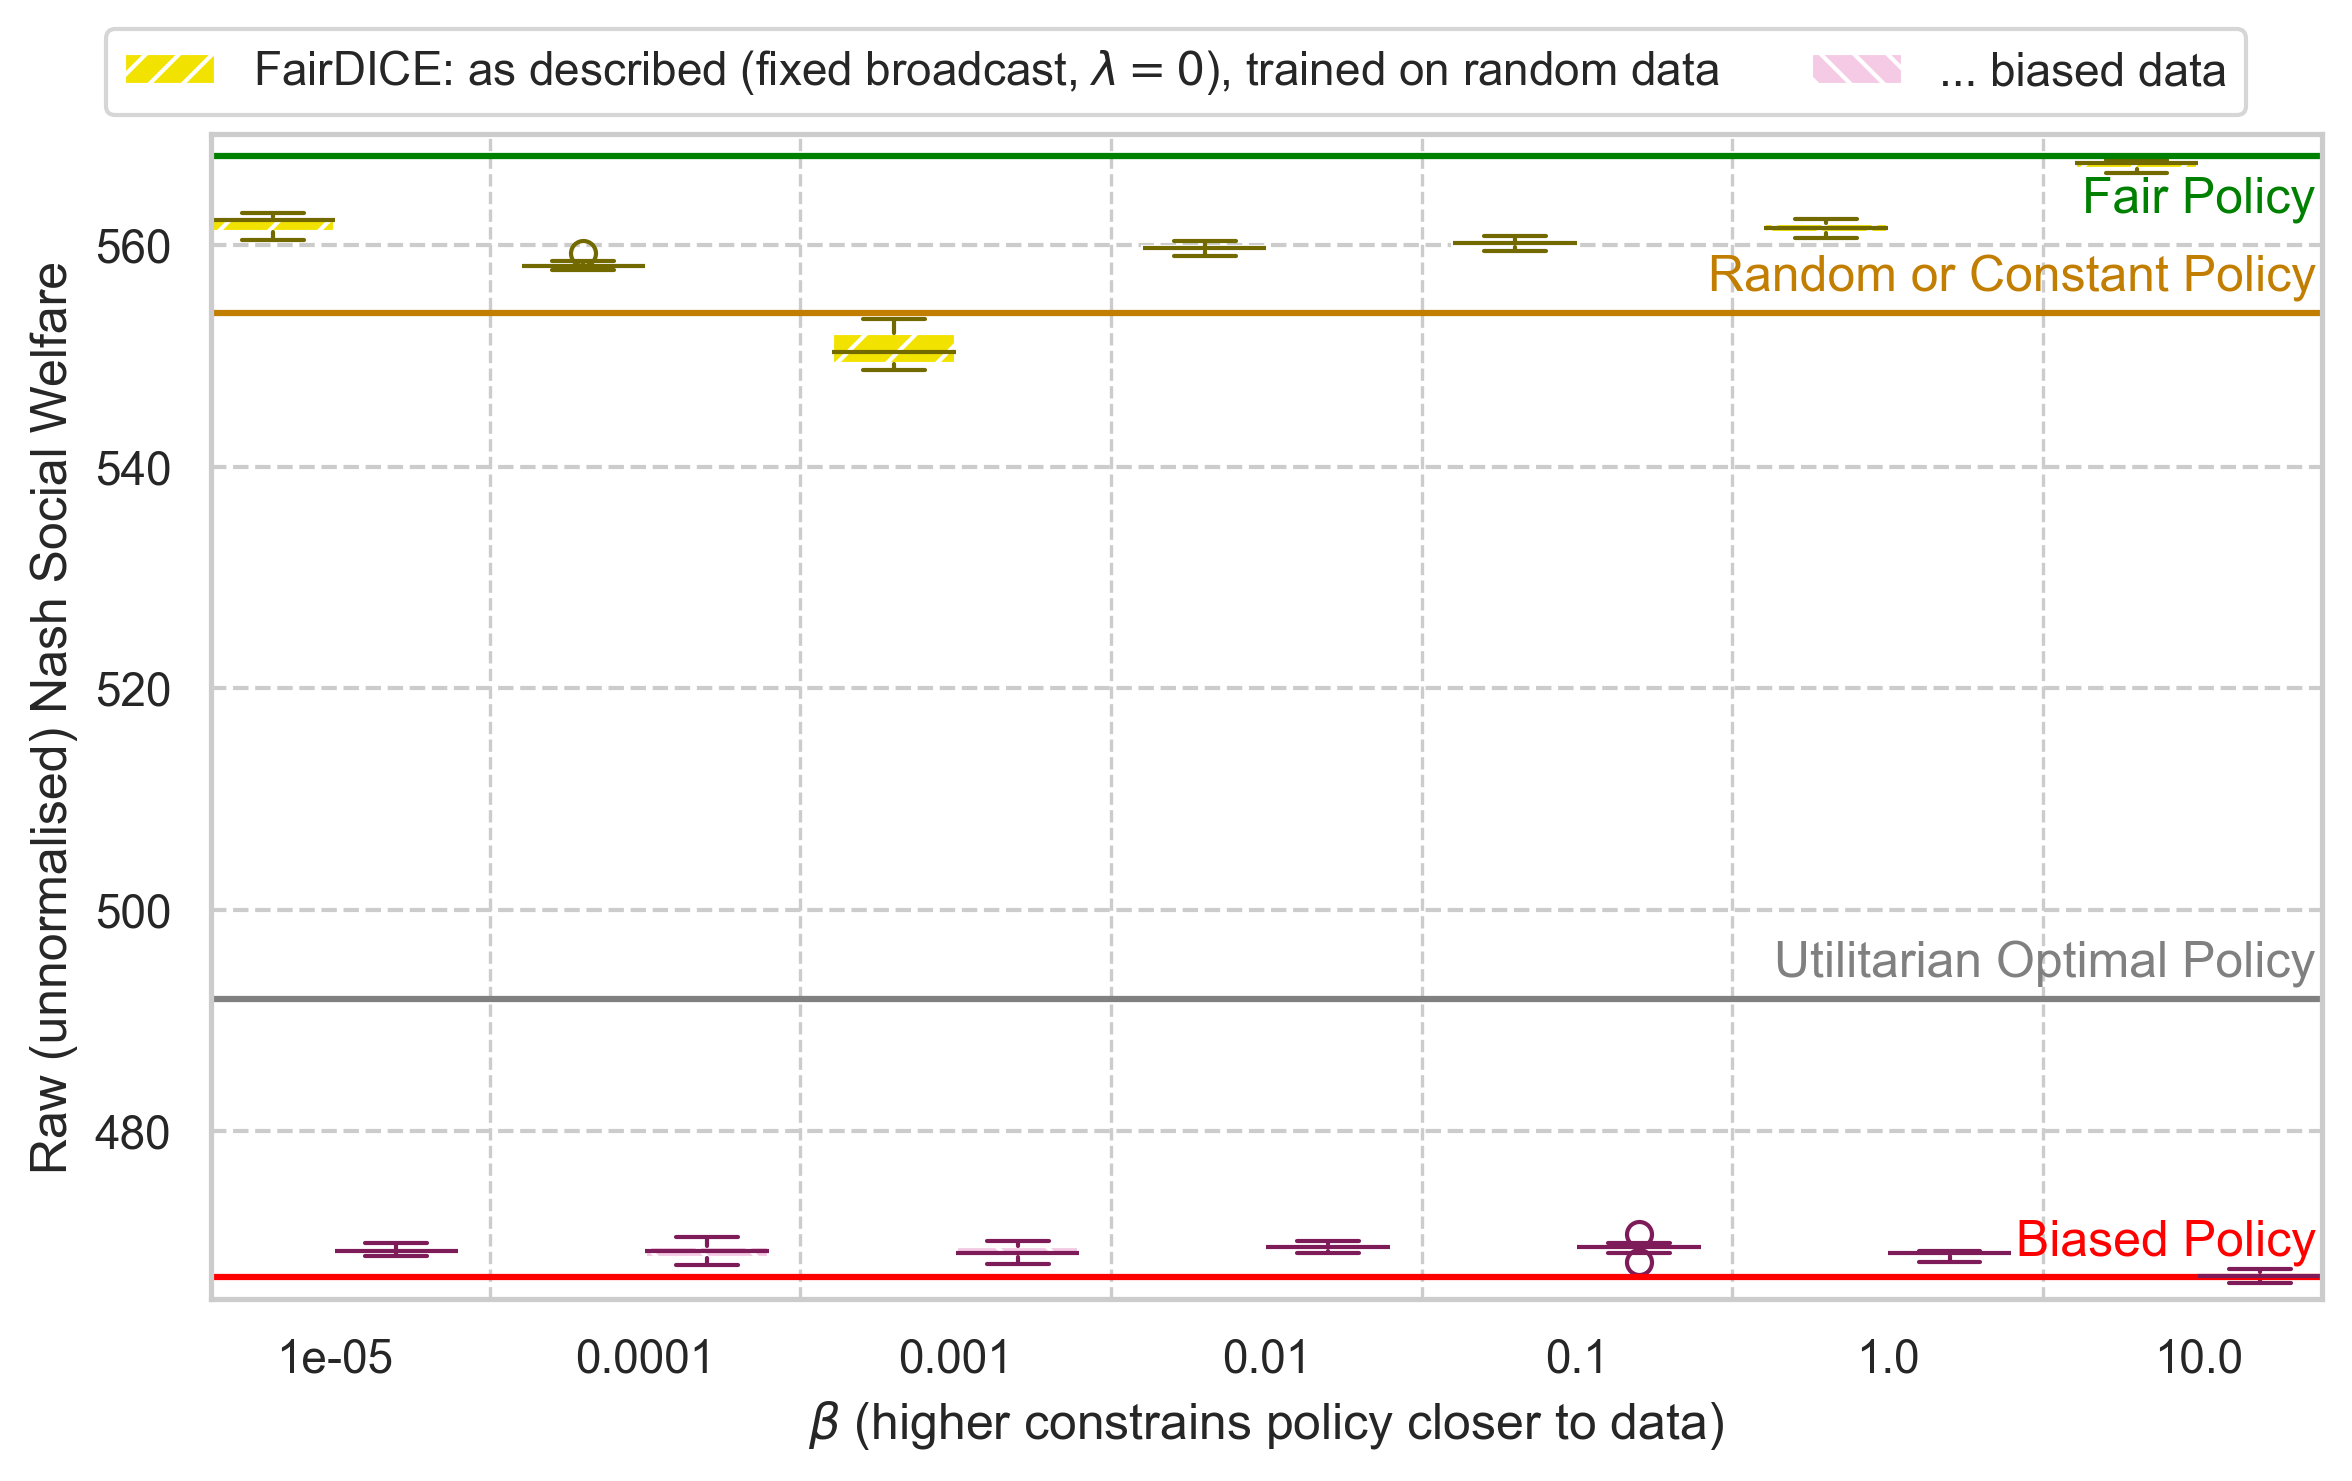

In [16]:
def show_group_policy_results():
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        tight_layout=True,
        figsize=(8, 5),
        dpi=300,
        sharey=True,
    )
    # If you ran experiments for multiple lambdas, you can visualise that too:
    # partitions = ("results-discrete-0", "results-discrete-0.0001")

    partitions = ("results-discrete-0",)
    # means of 100 seeds
    unfair = 466.879
    utilitarian = 491.899
    random = 553.889
    fair = 568.015

    style_kwargs = {
        "cols": ("#F1E200", plt.color_sequences["Pastel2"][3]),
        "hatches": ("/", "\\"),
        "group_names": (
            "FairDICE: as described (fixed broadcast, $\\lambda=0$), trained on random data",
            "... biased data",
        ),
    }
    data = np.concat(
        [
            gather_nsw_data(
                betas=standard_betas,
                expert=expert,
                name="GroupPolicy-v1",
                partitions=partitions,
                eval_dir="re-eval-100-sample",
                normalise_returns=False,
            )
            for expert in (False, True)
        ],
        axis=1,
    )
    grouped_bars(
        ax,
        standard_betas,
        data,
        kind="boxplot",
        autorange_groups=None,
        legend=False,
        dark_cols=("#726A00", "#7E1C59"),
        **style_kwargs,
    )
    expert = False
    ax.set_ylim(unfair - 2, fair + 2)
    ax.axhline(unfair, color="red")
    text_x = 0.003 if expert else 0.997
    hal = "left" if expert else "right"
    ax.text(
        text_x,
        475 if expert else unfair + 2,
        "Biased Policy",
        color="red",
        horizontalalignment=hal,
    )
    ax.axhline(random, color="#C27E00")
    ax.text(
        text_x,
        random + 2,
        "Random or Constant Policy",
        color="#C27E00",
        horizontalalignment=hal,
    )
    ax.axhline(utilitarian, color="gray")
    ax.text(
        text_x,
        utilitarian + 2,
        "Utilitarian Optimal Policy",
        color="gray",
        horizontalalignment=hal,
    )
    ax.axhline(fair, color="green")
    ax.text(text_x, 563, "Fair Policy", color="green", horizontalalignment=hal)
    ax: plt.Axes

    ax.set_ylabel("Raw (unnormalised) Nash Social Welfare")

    handles = legend_handles(**style_kwargs)
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.999),
        ncol=len(handles),
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


show_group_policy_results()

In [19]:
# Code for plotting the overivew of the PyTorch rewrite results.
# Not used in the paper

# make_box_grid(
#     kind="boxplot",
#     partitions=("old-results", "fix-results-grad0", "pt-fix-grad0"),
#     cols=(
#         plt.color_sequences["Pastel1"][0],
#         plt.color_sequences["Pastel1"][2],
#         plt.color_sequences["Pastel1"][6],
#     ),
#     hatches=("O", "x", "X"),
#     group_names=(
#         "FairDICE: as implemented",
#         "FairDICE: as described (fixed broadcast, no penalty)",
#         "FairDICE: PyTorch rewrite",
#     ),
# )

# Numerical results
You can copy the dictionaries from the outputs of the cells below to inspect our results.

In [23]:
def gather_return_data(
    name: str = "Hopper-v2",
    expert: bool = True,
    betas: tuple[float, ...] = standard_betas,
    partitions: tuple[str, ...] = standard_partitions,
):
    return np.stack(
        [
            np.stack(
                [
                    load_data(
                        name=name,
                        expert=expert,
                        partition=part,
                        beta=beta,
                        eval_dir="re-eval-100",
                    ).raw_returns.mean(1)
                    for part in partitions
                ]
            )
            for beta in betas
        ]
    )


gather_return_data().shape

(7, 5, 10, 2)

In [22]:
def make_value_dict(
    names: tuple[str, ...] = model_names, betas: tuple[float, ...] = standard_betas
):
    dct = {}
    for name in names:
        for expert in (False, True):
            valss = gather_nsw_data(
                betas=betas, expert=expert, name=name, eval_dir="re-eval-100"
            )
            for beta, vals in zip(betas, valss, strict=True):
                for algo, val in zip(
                    ("Rerun", "BC", "Fixed-Grad0", "Fixed-Grad0.0001", "Fixed-Grad0.1"),
                    vals,
                    strict=True,
                ):
                    dct[f"{name}/{'expert' if expert else 'amateur'}/{algo}/{beta}"] = (
                        val.round(4).tolist()
                    )
    print(dct)


make_value_dict()

{'Hopper-v2/amateur/Rerun/1e-05': [11.5709, 11.5724, 11.575, 11.5777, 11.5662, 11.5804, 11.5653, 11.5705, 11.5653, 11.572], 'Hopper-v2/amateur/BC/1e-05': [11.5745, 11.5686, 11.5671, 11.573, 11.5641, 11.565, 11.5727, 11.5755, 11.569, 11.5712], 'Hopper-v2/amateur/Fixed-Grad0/1e-05': [3.1413, 2.9343, 6.6112, 2.9436, 6.1984, 5.6417, 6.1083, 7.7688, 6.1278, 6.5514], 'Hopper-v2/amateur/Fixed-Grad0.0001/1e-05': [2.9531, 6.8524, 6.4766, 5.9884, 6.3298, 6.0679, 3.112, 3.4443, 5.05, 2.9428], 'Hopper-v2/amateur/Fixed-Grad0.1/1e-05': [6.6122, 6.6864, 6.0492, 6.5285, 6.9383, 6.9985, 6.6675, 7.2787, 6.2016, 5.7249], 'Hopper-v2/amateur/Rerun/0.0001': [11.5732, 11.5751, 11.5726, 11.5764, 11.5742, 11.5763, 11.5606, 11.577, 11.5679, 11.5693], 'Hopper-v2/amateur/BC/0.0001': [11.569, 11.5686, 11.5625, 11.565, 11.5729, 11.5773, 11.5668, 11.5727, 11.5635, 11.5641], 'Hopper-v2/amateur/Fixed-Grad0/0.0001': [9.004, 10.3639, 8.4834, 7.3708, 9.0035, 6.4516, 8.1971, 8.7765, 9.0993, 6.4275], 'Hopper-v2/amateur/Fix

In [24]:
def make_return_dict(
    names: tuple[str, ...] = model_names, betas: tuple[float, ...] = standard_betas
):
    dct = {}
    for name in names:
        for expert in (False, True):
            valss = gather_return_data(betas=betas, expert=expert, name=name)
            for beta, vals in zip(betas, valss, strict=True):
                for algo, val in zip(
                    ("Rerun", "BC", "Fixed-Grad0", "Fixed-Grad0.0001", "Fixed-Grad0.1"),
                    vals,
                    strict=True,
                ):
                    dct[f"{name}/{'expert' if expert else 'amateur'}/{algo}/{beta}"] = (
                        val.round(4).tolist()
                    )
    print(dct)


make_return_dict()

{'Hopper-v2/amateur/Rerun/1e-05': [[3180.1401, 4426.1663], [3207.2803, 4400.9898], [3231.6671, 4390.4275], [3259.8658, 4375.2904], [3180.9609, 4381.8357], [3262.8376, 4396.5394], [3195.756, 4351.4862], [3191.3748, 4406.1906], [3238.8851, 4290.7919], [3259.2238, 4323.3698]], 'Hopper-v2/amateur/BC/1e-05': [[3275.9759, 4324.1185], [3215.0049, 4354.6533], [3150.9598, 4433.1067], [3242.0051, 4357.2879], [3140.6469, 4419.7811], [3174.3529, 4379.0333], [3245.2598, 4350.0969], [3240.008, 4383.8195], [3234.3076, 4330.6676], [3257.8585, 4318.9353]], 'Hopper-v2/amateur/Fixed-Grad0/1e-05': [[37.2948, 11.9622], [31.9516, 11.2426], [158.7781, 64.6097], [33.1939, 10.8797], [118.7229, 78.0391], [102.3038, 45.8527], [114.5886, 67.0781], [427.9517, 66.337], [112.0854, 60.537], [158.0755, 76.7541]], 'Hopper-v2/amateur/Fixed-Grad0.0001/1e-05': [[34.7085, 10.2688], [155.8973, 166.4989], [150.1705, 70.9227], [111.7048, 59.0191], [136.9154, 81.4362], [109.7524, 87.0496], [33.3806, 12.8008], [38.972, 15.4194]